Ejemplo del libro de Ciaburro: https://github.com/PacktPublishing/Hands-On-Simulation-Modeling-with-Python-Second-Edition

$\int_0^3 x^2\, \mathrm{d}x$  (sabemos que tiene que dar 9)

In [12]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
random.seed(2)
f = lambda x: x**2
a = 0.0
b = 3.0
NumSteps = 1000000 

XIntegral=[] ; YIntegral=[]
XRectangle=[] ; YRectangle=[]

# buscamos los valores máximos y mínimos de la función en el intervalo [a,b]
ymin = f(a)
ymax = ymin
for i in range(NumSteps):
    x = a + (b - a) * float(i) / NumSteps
    y = f(x)
    if y < ymin: ymin = y
    if y > ymax: ymax = y


In [3]:
A = (b - a) * (ymax - ymin)
N = 1000000 
M = 0
for k in range(N):
    x = a + (b - a) * random.random()
    y = ymin + (ymax - ymin) * random.random()
    if y <= f(x):
            M += 1 
            XIntegral.append(x)
            YIntegral.append(y)  
    else:
            XRectangle.append(x) 
            YRectangle.append(y)              
NumericalIntegral = M / N * A
# si ymin es distinto de cero, hay que sumar el rectángulo de base (b-a) y altura ymin
if ymin != 0:
    NumericalIntegral += (b - a) * ymin
print ("Numerical integration = " + str(NumericalIntegral))

Numerical integration = 8.996787006398996


### Pregunta: ¿Por qué agregué el `if ymin != 0`?

Pensarlo y verlo graficamente!

Graficamos:

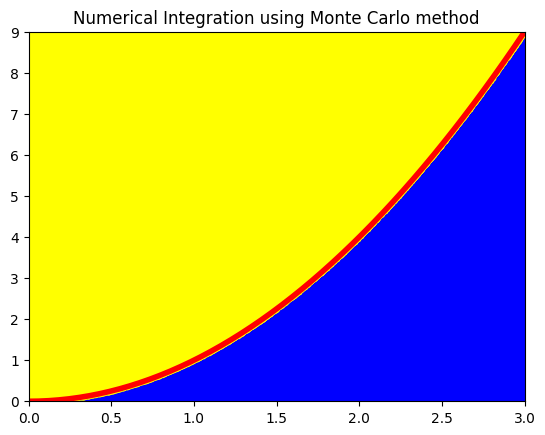

In [4]:
XLin=np.linspace(a,b)
YLin=[]
for x in XLin:
    YLin.append(f(x))

plt.axis   ([0, b, 0, f(b)])                                            
plt.plot   (XLin,YLin, color="red" , linewidth="4") 
plt.scatter(XIntegral, YIntegral, color="blue", marker   =".") 
plt.scatter(XRectangle, YRectangle, color="yellow", marker   =".")
plt.title  ("Numerical Integration using Monte Carlo method")
plt.show()

---

## Otros algoritmos

(de https://github.com/helcsnewsxd/models-and-simulation-subject)

Siguiendo secciones:

- 13.5 del libro de Averil M. Law (pág. 714)
- 3.2 del libro de Sheldon M. Ross (pág. 40)

In [5]:
def monteCarlo(f: callable, a: float, b: float, n: int) -> float:
    """
    Estimate the integral of f from a to b using the Monte Carlo method.
    a, b: interval [a, b]
    b is inf. if b is None
    """
    def estimate(f: callable, a: float, b: float, n: int) -> float:
        """
        Do the estimation method for fixed interval [a, b]
        """
        r = 0
        for i in range(n):
            x = random.random()
            r += f(a + (b - a) * x)
        return (b - a) * r / n

    g = lambda x: f(1/x - 1) / x**2
    match b:
        case None: return estimate(g, 0, 1, n) + estimate(f, a, 0, n)
        case _: return estimate(f, a, b, n)

Estimaremos las integrales con "n" iteraciones, usando desde $10^2$ a $10^7$

In [6]:
n_list = [10**i for i in range(2, 7)]

$\int_0^1 (1-x^2)^{3/2}\, \mathrm{d}x = \frac{3\pi}{16}\approx 0.58905$

In [8]:
f = lambda x: (1-x**2)**(3/2)
for n in n_list:
    print(f"    Para n = {n}: {monteCarlo(f, 0, 1, n)}")
print()

    Para n = 100: 0.5877734224532501
    Para n = 1000: 0.6089072900669616
    Para n = 10000: 0.585029978528427
    Para n = 100000: 0.5902734940860523
    Para n = 1000000: 0.5890893117802283



$\int_2^3 \frac{x}{(x^2-1)}dx = \frac{1}{2} \ln(8/3) \approx 0.4904$


In [9]:
f = lambda x: x/(x**2-1)
for n in n_list:
    print(f"    Para n = {n}: {monteCarlo(f, 2, 3, n)}")
print()

    Para n = 100: 0.4904679938946036
    Para n = 1000: 0.48860197690290125
    Para n = 10000: 0.49030244451406524
    Para n = 100000: 0.49021495845259216
    Para n = 1000000: 0.4904208115259008



$\int_0^\infty\, \frac{x}{(1+x^2)^2}\, dx = 0.5$

In [10]:
f = lambda x: x*(1+x**2)**(-2)
for n in n_list:
    print(f"    Para n = {n}: {monteCarlo(f, 0, None, n)}")
print()

    Para n = 100: 0.5376373128469298
    Para n = 1000: 0.502336793530885
    Para n = 10000: 0.49720512789006843
    Para n = 100000: 0.5014461129348977
    Para n = 1000000: 0.5001869300565757



$\int_{-\infty}^\infty e^{-x^2} dx = \sqrt{\pi} \approx 1.77245$

In [13]:
print(f"    Como es una funcion par, calculamos la integral en [0, inf] y la multiplicamos por 2")
f = lambda x: math.exp(-x**2)
for n in n_list:
    print(f"    Para n = {n}: {2*monteCarlo(f, 0, None, n)}")
print()

    Como es una funcion par, calculamos la integral en [0, inf] y la multiplicamos por 2
    Para n = 100: 1.7533733145911408
    Para n = 1000: 1.8167598843806945
    Para n = 10000: 1.7724477972557477
    Para n = 100000: 1.7736696465822315
    Para n = 1000000: 1.772531223325306



Agregamos otra subrutina para integrales múltiple:

In [15]:
def monteCarlo_multiple(f: callable, I: list[tuple[float, float]], n: int) -> float:
    """
    Estimate the multiple integral of function f over intervals in I using the Monte Carlo method.
    I[i][0], I[i][1]: interval [a, b]
        b is inf. if b is None => a must be 0
    f: function to integrate, takes a list of variables
    """
    def estimate(f: callable, I: list[tuple[float, float]], n: int) -> float:
        """
        Do the estimation method for fixed intervals
        """
        r = 0
        for i in range(n):
            x = [random.random() for _ in range(len(I))]
            r += f(x, I)
        m = 1
        for i in range(len(I)): m *= I[i][1] - I[i][0] if I[i][1] is not None else 1
        return m * r / n

    def g(x: list[float], I: list[tuple[float, float]]) -> float:
        """
        Function to estimate with fixed intervals [a, b]
        """
        denominator = 1
        for i in range(len(I)):
            if I[i][1] is None:
                assert I[i][0] == 0
                denominator *= x[i]**2
                x[i] = 1/x[i] - 1
            else:
                x[i] = I[i][0] + (I[i][1] - I[i][0]) * x[i]
        return f(x) / denominator

    return estimate(g, I, n)

$\int_0^1 \left(\, \int_0^1 e^{(x+y)^2}\, dx\right) dy = 4.8991$

In [16]:
f = lambda x: math.exp((x[0]+x[1])**2)
for n in n_list:
    print(f"    Para n = {n}: {monteCarlo_multiple(f, [(0, 1), (0, 1)], n)}")
print()

    Para n = 100: 5.023771830050503
    Para n = 1000: 4.667521394339194
    Para n = 10000: 5.016433629678046
    Para n = 100000: 4.885650846627288
    Para n = 1000000: 4.891809167335874

